# 03 — Task 2: PCA + KNN

Apply PCA to the 5000 TF-IDF features; classify with **KNN `n_neighbors=2`** (sklearn allowed). Report test Macro F1 at exactly **2000, 1000, 500, 100** components — each read back from Kaggle. These four counts are graded and override the scree-elbow rule.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

from src import paths, data, evaluation


## 1. Load features + the locked split

In [2]:
X, y, ids = data.load_train_features()
Xt, test_ids = data.load_test_features()

## 2. PCA + KNN at the four required component counts

In [5]:
COMPONENT_COUNTS = [2000, 1000, 500, 100]
for n in COMPONENT_COUNTS:
    pipe = make_pipeline(PCA(n_components=n, random_state=42),
                         KNeighborsClassifier(n_neighbors=2))
    # fit on train, predict test, write per-variant submission, log Kaggle Macro F1
    pipe.fit(X, y)
    preds = pipe.predict(Xt)
    data.write_submission(test_ids, preds, f'pca_knn_{n}_components.csv')

## 3. Analysis of the reduced components

Required for full marks: discuss explained variance, what PCA captures, and the accuracy/components trade-off.

In [7]:
# One 2000-component fit serves every point on the curve: PCA components are
# variance-ordered, so the first n columns of a 2000-fit are exactly the n-fit.
# Slow (~minutes) on the 20000 x 5000 matrix - run once, then restyle in the next cell.
pca_full = PCA(n_components=2000, random_state=42)
pca_full.fit(X)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Kaggle leaderboard scores for the four graded submissions.
KAGGLE_MACRO_F1 = {100: 0.67793, 500: 0.66373, 1000: 0.55923, 2000: 0.41495}
counts = sorted(KAGGLE_MACRO_F1)

# cum_evr[n - 1] is the variance retained by the FIRST n components (not cum_evr[n]).
cum_at = [cum_evr[n - 1] for n in counts]
f1_at = [KAGGLE_MACRO_F1[n] for n in counts]

for n, v, f in zip(counts, cum_at, f1_at):
    print(f"{n:>5} components   cumulative EVR = {v:6.2%}   Kaggle macro F1 = {f:.5f}")

if cum_evr[-1] >= 0.90:
    print(f"\n90% of variance reached at {int(np.searchsorted(cum_evr, 0.90)) + 1} components")
else:
    print(f"\n90% not reached within 2000 components (max {cum_evr[-1]:.2%})")

  100 components   cumulative EVR = 15.82%   Kaggle macro F1 = 0.67793
  500 components   cumulative EVR = 38.95%   Kaggle macro F1 = 0.66373
 1000 components   cumulative EVR = 56.43%   Kaggle macro F1 = 0.55923
 2000 components   cumulative EVR = 76.96%   Kaggle macro F1 = 0.41495

90% not reached within 2000 components (max 76.96%)


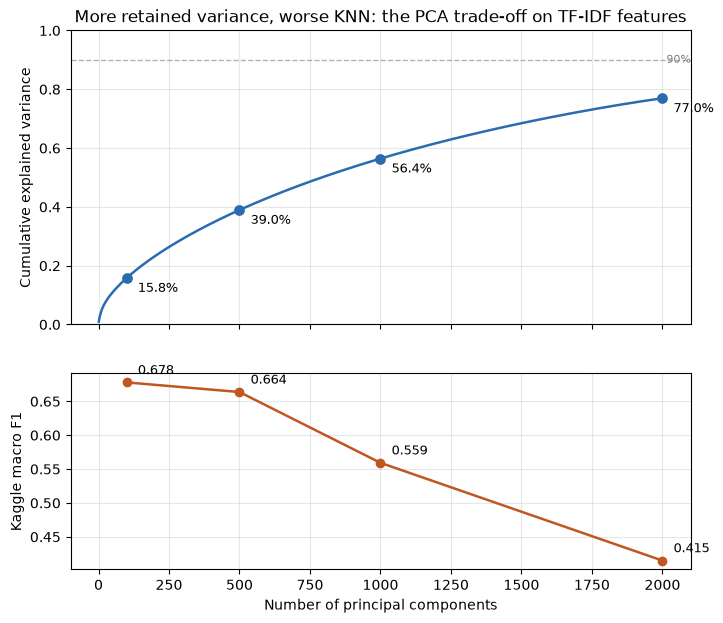

In [8]:
import matplotlib.pyplot as plt

from src import plotting

# Stacked panels sharing the x-axis rather than a twin-axis chart: two y-scales on
# one frame make the crossover point look meaningful when it is only a scaling artifact.
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 7), gridspec_kw={"height_ratios": [3, 2]}
)

x = np.arange(1, len(cum_evr) + 1)
ax1.plot(x, cum_evr, color="#2b6cb0", lw=1.8)
ax1.scatter(counts, cum_at, color="#2b6cb0", s=45, zorder=3)
for n, v in zip(counts, cum_at):
    ax1.annotate(f"{v:.1%}", (n, v), textcoords="offset points", xytext=(8, -10), fontsize=9)
ax1.axhline(0.90, ls="--", lw=1, color="grey", alpha=0.6)
ax1.text(x[-1], 0.90, " 90%", va="center", fontsize=8, color="grey")
ax1.set_ylabel("Cumulative explained variance")
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)
ax1.set_title("More retained variance, worse KNN: the PCA trade-off on TF-IDF features")

ax2.plot(counts, f1_at, marker="o", color="#c05621", lw=1.8)
for n, f in zip(counts, f1_at):
    ax2.annotate(f"{f:.3f}", (n, f), textcoords="offset points", xytext=(8, 6), fontsize=9)
ax2.set_xlabel("Number of principal components")
ax2.set_ylabel("Kaggle macro F1")
ax2.grid(alpha=0.3)

plt.show()  # before save_fig - it closes the figure
plotting.save_fig(fig, "pca_cumulative_variance_vs_f1.png")

In [ ]:
# The Discussion below turns on the predicted class balance, so read it off the four
# submission files rather than asserting it in prose. This needs no Kaggle slot: the
# share is a property of the file we uploaded, not of the score that came back.
#
# The comparison is against 0.6252**2, which is where the share would settle if degraded
# retrieval merely made the two neighbours independent draws from the training prior.
# That value is a floor under that account, so falling below it rules the account out.
PRIOR = y.mean()
FLOOR = PRIOR ** 2

rows = []
for n in counts:
    lab = pd.read_csv(paths.SUBMISSIONS / f"pca_knn_{n}_components.csv",
                      dtype={"id": str})["label"].to_numpy()
    share = lab.mean()
    rows.append({"components": n, "cum_evr": cum_evr[n - 1], "share": share,
                 # q solves share = q**2, i.e. the rate at which a single retrieved
                 # neighbour is machine, given that both must be for a machine call
                 "implied_q": np.sqrt(share),
                 "kaggle_f1": KAGGLE_MACRO_F1[n]})

shares = pd.DataFrame(rows)
print(shares.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\ntraining prior {PRIOR:.4f}, independent-draw floor {FLOOR:.4f}")
print(f"share at {counts[-1]} components is {shares['share'].iloc[-1] - FLOOR:+.4f} "
      f"relative to that floor")
if shares["share"].iloc[-1] < FLOOR:
    print("Below the floor, so the neighbours are systematically human, not random. "
          "See the Discussion for the hubness reading.")

shares.to_csv(paths.DATA_PROCESSED / "pca_knn_components_results.csv", index=False)


## Discussion / carry-forward → `04_models.ipynb`

### Results

| Components | Cumulative explained variance | Predicted machine share | Kaggle Macro F1 |
|---|---|---|---|
| 100 | 15.82% | 0.5449 | 0.67793 |
| 500 | 38.95% | 0.3686 | 0.66373 |
| 1000 | 56.43% | 0.1767 | 0.55923 |
| 2000 | 76.96% | 0.0590 | 0.41495 |

Keeping more variance made the classifier steadily worse. The best score came from the most aggressive reduction, 100 components, which holds under a sixth of the total variance.

### What PCA captures here

PCA is unsupervised, so it never sees the labels. It finds the directions of maximum variance in the TF-IDF space, and variance is not the same thing as class separation. Nothing guarantees that the directions it keeps are useful for telling the two classes apart, at any component count.

The spectrum is also very flat. We never reach 90% of variance within 2000 components; the maximum is 76.96%. Keeping 40% of the original 5000 dimensions recovers only about three quarters of the variance, so there is no low rank structure here for PCA to exploit.

### Why more components hurt KNN

1. **Distance concentration.** In higher dimensions, the distance from a query point to its nearest neighbour and to its farthest neighbour start to converge, with the ratio between them tending towards 1. KNN assumes that "nearest" means "most similar", and it is exactly that contrast which disappears.

2. **The extra directions are mostly noise, and Euclidean distance cannot down-weight them.** Components past the leading few capture term co-occurrence that is specific to individual documents rather than shared across a class. Any single tail component contributes very little to the distance, since its contribution scales with its variance, but there are enough of them that together they take over. At 2000 components, (76.96% - 15.82%) / 76.96% is about 79%, so roughly 79% of the squared distance comes from directions outside the top 100. At 1000 components it is 72%, and at 500 it is 59%. The distance itself gets noisier as we add components.

3. **The tie-break rule converts degraded retrieval into a near-constant "human" prediction.** With k=2 and two classes the neighbours can split 1-1. sklearn breaks ties by lowest class index, which here is label 0, human. So the model predicts machine only when *both* neighbours are machine, and anything that degrades retrieval is amplified by being squared.

   The predicted machine share column above measures the damage directly, and it is far worse than a prior-driven account would allow. If degraded retrieval simply made the two neighbours behave like independent draws from the 62.52% training prior, the share would fall towards 0.6252² = 0.3909 and stop there. That value is a floor under that account. The observed share at 2000 components is **0.0590**, which is 0.33 *below* the floor, so the neighbours are not random draws: they are systematically human.

   Backing out the implied per-neighbour machine rate as q = √share makes the size of the effect explicit:

   | Components | 100 | 500 | 1000 | 2000 |
   |---|---|---|---|---|
   | implied q | 0.738 | 0.607 | 0.420 | 0.243 |

   Under the prior-driven account q should sit at 0.6252 at every count. Instead it falls monotonically to 0.243, well under the prior. A retrieved neighbour is machine only about a quarter of the time even though machine rows are 62.52% of the training set.

   The standard explanation for this shape is **hubness**: as dimension grows, a small number of training points become the nearest neighbour of disproportionately many queries, and the rest are retrieved by almost nobody. If those hub points skew human, most queries pick up at least one human neighbour, the 1-1 tie fires, and the tie-break sends the prediction to human. That is consistent with everything measured here, but we have not measured the k-occurrence distribution itself, so hubness remains the leading explanation rather than a demonstrated one. Counting how often each training row appears in a test row's 2-neighbour list, and the human fraction among the most frequent, would settle it.

   The score at 2000 components is what this predicts. Labelling 94% of rows human on a test set that is roughly half machine leaves the machine class F1 near zero, which is how 0.41495 arises. It is close to the ~0.385 of a single-class predictor because at 0.0590 the model is very nearly one.

### Carry-forward

- For KNN on these features, fewer components is simply better. PCA is acting as a denoiser here, and all of the benefit sits at the aggressive end. The four counts are fixed by the task, but 100 may not be the floor; 20 to 50 components could plausibly do better.
- The failure is as much the **k=2 tie-break** as the dimensionality. k=3, or `weights="distance"`, would break ties on evidence instead of class index and should be far less sensitive to component count. Both are outside Task 2's fixed spec, which mandates `n_neighbors=2`, so this is a remark for the report rather than a change to make here.
- The share diagnostic used above (read the predicted class balance off a submission file before trusting its score) transfers directly to Task 3, where predicted share turns out to be the dominant driver of leaderboard score.